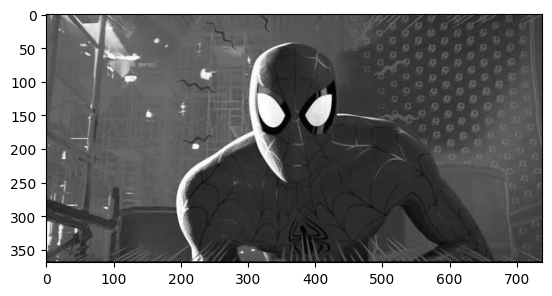

In [66]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 

img = cv2.imread("images (3).jpg", cv2.IMREAD_GRAYSCALE)  
plt.imshow(img, cmap="gray")
plt.show()

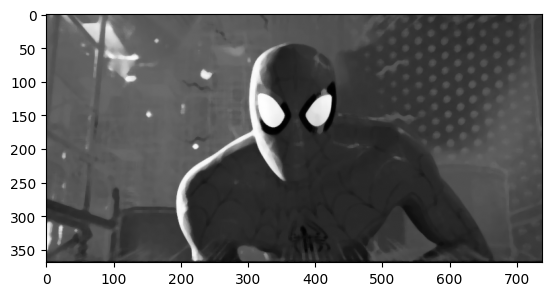

In [67]:
mb = cv2.medianBlur(img, 7)
plt.imshow(mb, cmap="gray")
plt.show()

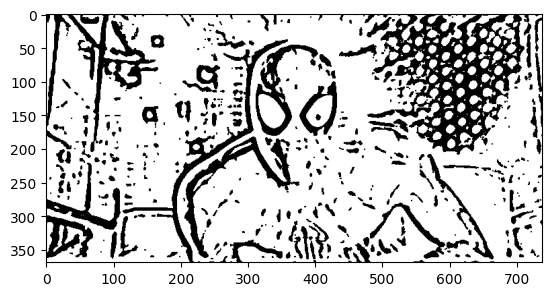

In [83]:
kernel = np.ones((2, 2), np.uint8)
edges = cv2.adaptiveThreshold(mb, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, blockSize=15, C = 3)
clean_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
plt.imshow(clean_edges, cmap="gray")
plt.show()

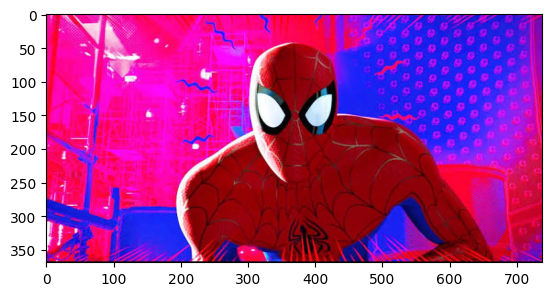

In [55]:
image = cv2.imread("images (3).jpg")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

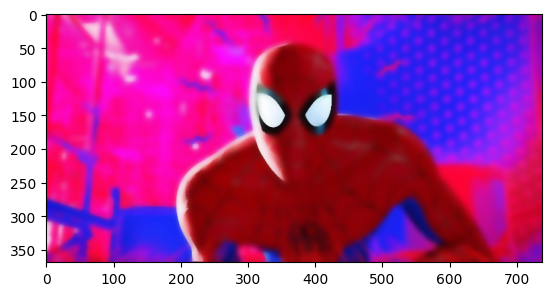

In [56]:
smooth = image.copy()
for _ in range(2):
    smooth = cv2.bilateralFilter(smooth, d=12, sigmaColor=200, sigmaSpace=7)
plt.imshow(cv2.cvtColor(smooth, cv2.COLOR_BGR2RGB))
plt.show()

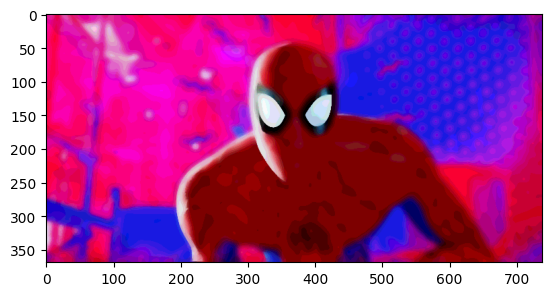

In [57]:
def quantize_color(image, levels=10):
    factor = 256 // levels
    quantized = (image // factor) * factor
    return quantized.astype(np.uint8)

result = quantize_color(smooth, levels=10)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()

In [58]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blank_canvas = np.full(gray.shape, 255, dtype=np.uint8)
h,w = gray.shape

In [59]:
for y in range(0, h, 6):
    for x in range(0, w, 6):
        brightness = gray[y, x]
        if brightness < 150:
            radius = max(1, int((1 - brightness/150) * 4))
            cv2.circle(blank_canvas, (x,y), radius, 0 ,-1)

In [84]:
edges_3 = cv2.cvtColor(clean_edges, cv2.COLOR_GRAY2BGR)
blank_canvas_3 = cv2.cvtColor(blank_canvas, cv2.COLOR_GRAY2BGR)

In [85]:
float_edges = (edges_3 / 255).astype(np.float32)
float_canvas = (blank_canvas_3 / 255).astype(np.float32)
float_quantized = (result / 255).astype(np.float32)

In [86]:
multiplied = float_edges * float_canvas * float_quantized

In [87]:
disp_img = (multiplied * 255).astype(np.uint8)

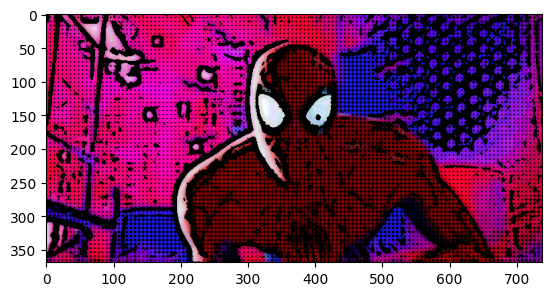

In [88]:
plt.imshow(cv2.cvtColor(disp_img, cv2.COLOR_BGR2RGB))
plt.show()